In [ ]:
# !pip install tensorflow
# pandas openpyxl scikit-learn seaborn keras tensorflow

In [76]:
import pandas as pd

Data = pd.read_csv('/kaggle/input/datasets/virgintarek/bengaluru-house-prices-csv/bengaluru_house_prices.csv')
Data.head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [77]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [78]:
summary = Data.describe()
print(summary)

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [79]:
Data = Data.drop(['society'], axis=1)

Data = Data.dropna(subset=['location', 'size', 'bath'])

Data['balcony'] = Data['balcony'].fillna(Data['balcony'].median())

Data.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [80]:
Data['BHK'] = Data['size'].apply(lambda x: int(str(x).split(' ')[0]))
Data = Data.drop(['size'], axis=1)
Data[['BHK']].describe()

,BHK
count,13246.000000
mean,2.801902
std,1.295758
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,43.000000


In [81]:
def convert_sqft(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        try:
            return (float(tokens[0]) + float(tokens[1])) / 2
        except ValueError:
            return None
    try:
        return float(x)
    except ValueError:
        return None

Data['total_sqft'] = Data['total_sqft'].apply(convert_sqft)
Data = Data.dropna(subset=['total_sqft'])
Data.shape

(13200, 8)

In [82]:
Data['availability'] = Data['availability'].apply(lambda x: 1 if x == 'Ready To Move' else 0)

In [83]:
Data['location'] = Data['location'].apply(lambda x: str(x).strip())
loc_counts = Data['location'].value_counts()
rare_locations = loc_counts[loc_counts <= 30].index
Data['location'] = Data['location'].apply(lambda x: 'other' if x in rare_locations else x)
print('Number of location categories kept:', Data['location'].nunique())

Number of location categories kept: 97


In [84]:
Data = pd.get_dummies(Data, columns=['area_type', 'location'], drop_first=True)
bool_cols = Data.select_dtypes(include='bool').columns
Data[bool_cols] = Data[bool_cols].astype(int)
Data.shape

(13200, 105)

In [85]:
Data = Data[~(Data['total_sqft'] / Data['BHK'] < 300)]

# Put the target column ('price') last, like CCS was last in the concrete dataset
cols = [c for c in Data.columns if c != 'price'] + ['price']
Data = Data[cols]
Data.shape

(12456, 105)

<Axes: >

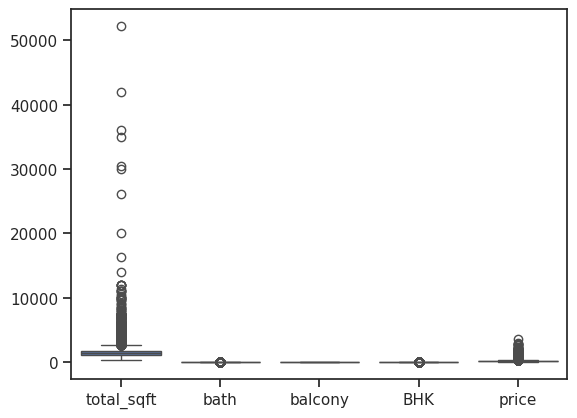

In [86]:
import seaborn as sns
sns.set(style="ticks")

continuous_cols = ['total_sqft', 'bath', 'balcony', 'BHK', 'price']
sns.boxplot(data=Data[continuous_cols])

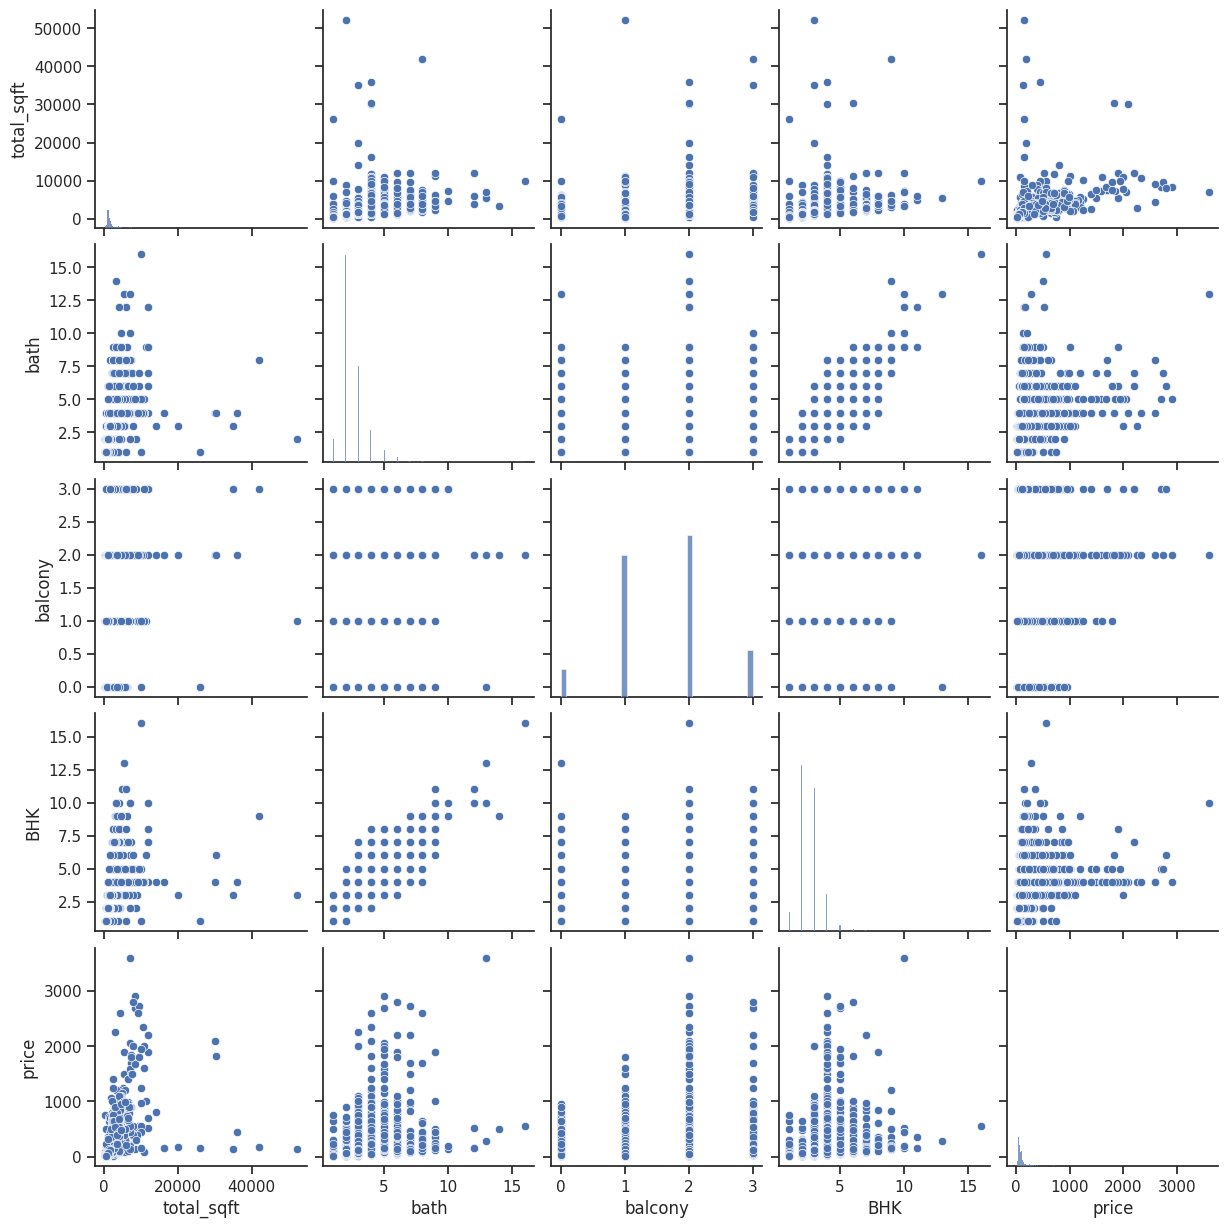

In [87]:
sns.pairplot(data=Data[continuous_cols])

In [88]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
print(scaler.fit(Data))

MinMaxScaler()


In [89]:
DataScaled = scaler.fit_transform(Data)
DataScaled = pd.DataFrame(DataScaled, columns=Data.columns)

In [90]:
summary = DataScaled.describe()
print(summary)

       availability    total_sqft          bath       balcony           BHK  \
count  12456.000000  12456.000000  12456.000000  12456.000000  12456.000000   
mean       0.787813      0.024825      0.104185      0.534093      0.109934   
std        0.408873      0.024252      0.072018      0.266005      0.065070   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        1.000000      0.015682      0.066667      0.333333      0.066667   
50%        1.000000      0.019241      0.066667      0.666667      0.133333   
75%        1.000000      0.026938      0.133333      0.666667      0.133333   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

       area_type_Carpet  Area  area_type_Plot  Area  \
count            12456.000000          12456.000000   
mean                 0.006583              0.109827   
std                  0.080872              0.312686   
min                  0.000000              0.000000   
25%          

In [91]:
from sklearn.model_selection import train_test_split

Predictors = DataScaled.drop('price', axis=1)
Response = DataScaled[['price']]

n_features = Predictors.shape[1]
print('Number of predictor columns:', n_features)

Number of predictor columns: 104


In [92]:
Pred_train, Pred_test, Resp_train, Resp_test = train_test_split(
    Predictors, Response, test_size=0.2, random_state=1)  # 20% of the data is held out as test data

print(Pred_train.shape)
print(Pred_test.shape)
print(Resp_train.shape)
print(Resp_test.shape)

(9964, 104)
(2492, 104)
(9964, 1)
(2492, 1)


In [93]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam, SGD, RMSprop

# fully connected neural network, regression output
model = Sequential()

model.add(Input(shape=(n_features,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

E0000 00:00:1786922282.189969    1690 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [94]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [95]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         6,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,345 (36.50 KB)

 Trainable params: 9,345 (36.50 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
history = model.fit(Pred_train, Resp_train, epochs=60, verbose=1,
                     validation_split=0.2, batch_size=64)

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0015 - mae: 0.0202 - val_loss: 0.0013 - val_mae: 0.0155
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - mae: 0.0158 - val_loss: 0.0012 - val_mae: 0.0146
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - mae: 0.0144 - val_loss: 0.0012 - val_mae: 0.0158
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.8859e-04 - mae: 0.0144 - val_loss: 0.0011 - val_mae: 0.0137
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2932e-04 - mae: 0.0139 - val_loss: 0.0011 - val_mae: 0.0158
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6811e-04 - mae: 0.0134 - val_loss: 0.0010 - val_mae: 0.0141
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.0601e-04 - mae: 0.0130 - val_loss: 0.0011 - val_mae: 0.0187
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9811e-04 - mae: 0.0137 - val_loss: 0.0012 - val_mae: 0.0164
Epoch 9/60
125/125 ━━━━━━━━━━━━━━━━━

 37/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021 - mae: 0.0307 

 75/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0019 - mae: 0.0255

113/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - mae: 0.0228

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - mae: 0.0227 - val_loss: 0.0013 - val_mae: 0.0174


...

  1/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 3.5454e-04 - mae: 0.0105

 39/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.5847e-04 - mae: 0.0089 

 78/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6791e-04 - mae: 0.0091

117/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.3166e-04 - mae: 0.0093

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.2820e-04 - mae: 0.0093 - val_loss: 7.4793e-04 - val_mae: 0.0113


In [97]:
from sklearn.metrics import r2_score

y_predKM = model.predict(Pred_test)
print('Coefficient of determination of Keras Model')
print(r2_score(Resp_test, y_predKM))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Coefficient of determination of Keras Model
0.5842592716217041


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


Coefficient of determination of Keras Model
0.6255199313163757


In [98]:
continuous_cols = ['total_sqft', 'bath', 'balcony', 'BHK', 'price']
Q1 = DataScaled[continuous_cols].quantile(0.25)
Q3 = DataScaled[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

total_sqft    0.011256
bath          0.066667
balcony       0.333333
BHK           0.066667
price         0.018379
dtype: float64


In [99]:
mask = ~((DataScaled[continuous_cols] < (Q1 - 1.5 * IQR)) |
         (DataScaled[continuous_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
DataScaledOut = DataScaled[mask]
DataScaledOut.shape

(10727, 105)

Text(0.5, 1.0, 'Data without outliers')

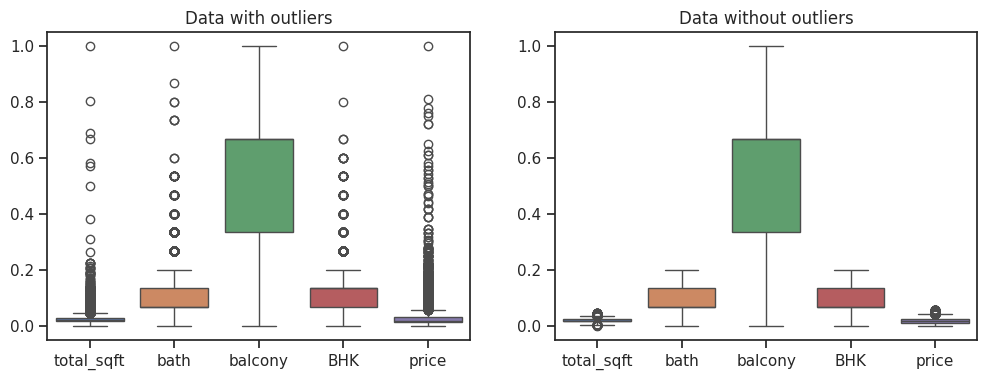

In [100]:
import matplotlib.pyplot as plt
plt.figure(1, figsize=(12, 4))
plt.subplot(121)
sns.boxplot(data=DataScaled[continuous_cols])
plt.title("Data with outliers")

plt.subplot(122)
sns.boxplot(data=DataScaledOut[continuous_cols])
plt.title("Data without outliers")

In [104]:
Predictors2 = DataScaledOut.drop('price', axis=1)
Response2 = DataScaledOut[['price']]

In [105]:
Pred_train2, Pred_test2, Resp_train2, Resp_test2 = train_test_split(
    Predictors2, Response2, test_size=0.2, random_state=1)  # 20% held out as test data

print(Pred_train2.shape)
print(Pred_test2.shape)
print(Resp_train2.shape)
print(Resp_test2.shape)

(8581, 104)
(2146, 104)
(8581, 1)
(2146, 1)


In [106]:
# fully connected neural network, same architecture, trained on the outlier-free data
model2 = Sequential()
model2.add(Input(shape=(Pred_train2.shape[1],)))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='linear'))

model2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         6,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,345 (36.50 KB)

 Trainable params: 9,345 (36.50 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
history2 = model2.fit(Pred_train2, Resp_train2, epochs=60, verbose=1,
                       validation_split=0.2, batch_size=64)

Epoch 1/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0011 - mae: 0.0190 - val_loss: 1.6990e-04 - val_mae: 0.0090
Epoch 2/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1879e-04 - mae: 0.0079 - val_loss: 1.1641e-04 - val_mae: 0.0074
Epoch 3/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.4295e-05 - mae: 0.0068 - val_loss: 8.8270e-05 - val_mae: 0.0068
Epoch 4/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1905e-05 - mae: 0.0063 - val_loss: 8.2079e-05 - val_mae: 0.0067
Epoch 5/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5852e-05 - mae: 0.0060 - val_loss: 6.7845e-05 - val_mae: 0.0058
Epoch 6/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0646e-05 - mae: 0.0058 - val_loss: 6.7336e-05 - val_mae: 0.0057
Epoch 7/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.8059e-05 - mae: 0.0057 - val_loss: 6.9462e-05 - val_mae: 0.0058
Epoch 8/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7433e-05 - mae: 0.0056 - val_loss: 6.1526e-05 - val_mae: 0.0

 36/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013 - mae: 0.0252    

 71/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.4391e-04 - mae: 0.0180

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.4220e-04 - mae: 0.0150

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.4220e-04 - mae: 0.0150 - val_loss: 1.2124e-04 - val_mae: 0.0082


...

  1/108 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.6401e-05 - mae: 0.0037

 34/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5084e-05 - mae: 0.0042 

 69/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6813e-05 - mae: 0.0042

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6853e-05 - mae: 0.0042

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7325e-05 - mae: 0.0043 - val_loss: 4.9709e-05 - val_mae: 0.0055


In [108]:
Y_predKM2 = model2.predict(Pred_test2)
print('Coefficient of determination of Neural Network Model without outliers')
print(r2_score(Resp_test2, Y_predKM2))

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Coefficient of determination of Neural Network Model without outliers
0.5781421065330505


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


Coefficient of determination of Neural Network Model without outliers
0.5550310611724854


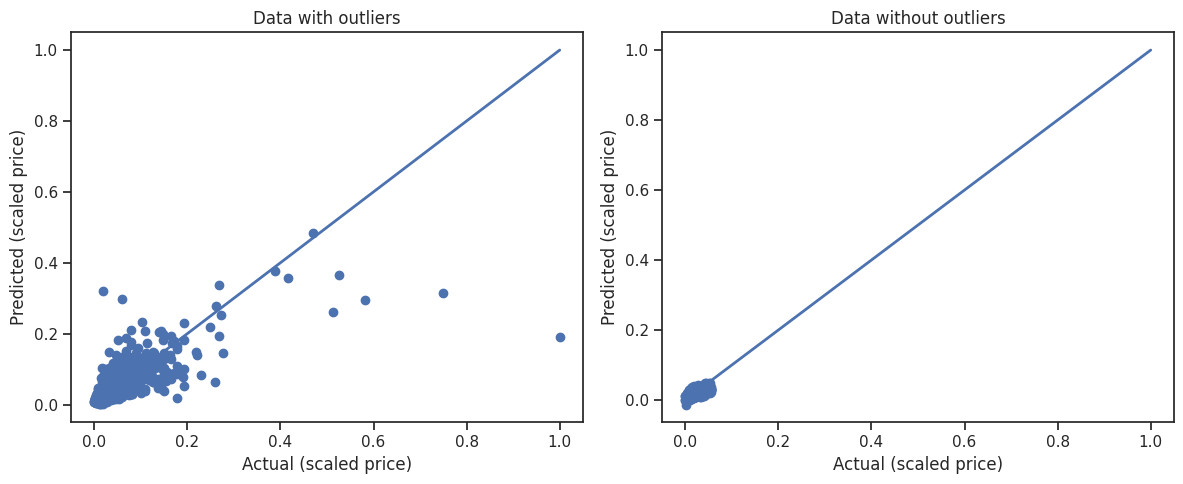

In [109]:
plt.figure(1, figsize=(12, 5))
plt.subplot(121)
plt.scatter(Resp_test, y_predKM)
plt.plot([0, 1], [0, 1], linewidth=2)
plt.xlabel("Actual (scaled price)")
plt.ylabel("Predicted (scaled price)")
plt.title("Data with outliers")

plt.subplot(122)
plt.scatter(Resp_test2, Y_predKM2)
plt.plot([0, 1], [0, 1], linewidth=2)
plt.xlabel("Actual (scaled price)")
plt.ylabel("Predicted (scaled price)")
plt.title("Data without outliers")
plt.tight_layout()
plt.show()